In [2]:
# source rename for review anonymisation
rename_tbl = {
    'cf_a': 'BOS 1',
    'cf_b': 'BOS 2',
    'cf_c': 'DXB 1',
    'cf_d': 'DXB 2',
    'cf_e': 'SIN 1',
    'cf_f': 'SIN 2',
    'cf_g': 'FRA 1',
    'cf_h': 'FRA 2',
    'fb_a': 'Meta 1',
    'fb_b': 'Meta 2',
    'fb_c': 'Meta 3',
    'wm_t': 'WM 1',
    'wm_u': 'WM 2',

    '106m105': 'BOS 1',
    '106m106': 'BOS 2',
    '243m12': 'DXB 1',
    '243m13': 'DXB 2',
    '411m264': 'SIN 1',
    '411m325': 'SIN 2',
    '472m378': 'FRA 1',
    '472m379': 'FRA 2',

    'fb_reag' : 'Meta 1',
    'fb_rhna' : 'Meta 2',
    'fb_rprn' : 'Meta 3',
}

def get_linestyle(source):
    if source.startswith('cf'):
        return 'solid'
    elif source.startswith('fb'):
        return 'dashed'
    elif source.startswith('wm'):
        return 'dotted'
    else:
        return 'solid'

In [3]:
%cd analysis

/home/isaackhor/code/cfcache/analysis


In [4]:
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pylab as pylab
params = {
    'legend.fontsize': 'large',
    'figure.figsize': (6, 4),
    'axes.labelsize': 'large',
    'axes.titlesize':'large',
    'xtick.labelsize':'large',
    'ytick.labelsize':'large',
    # 'title.fontsize': 'x-large',
}
pylab.rcParams.update(params)

cols = ['ts', 'next_ts', 'ttl', 'create_ts', 'freq', 'last_ts', 'update_ts', 'revals', 'good_rv', 'bad_rv', 'mime']
dfs = []
for c in ['cf_a', 'cf_b', 'cf_c', 'cf_d','cf_e', 'cf_f','cf_g', 'cf_h', 'fb_a', 'fb_b', 'fb_c']:
    sdf = pd.read_csv(f'../traces/expiry/r10{c}.csv.zst', names=cols, skiprows=lambda i: random.random() > 0.01)
    sdf['in'] = c
    sdf['trace'] = rename_tbl.get(c, c)
    dfs.append(sdf)
df = pd.concat(dfs)
df['should_reval'] = (df['ts'] <= df['next_ts']) & (df['next_ts'] <= (df['ts'] + df['ttl'])) & (df['ttl'] < 7 * 86400)
df['generations'] = ((df['ts'] - df['create_ts'] - 1) / df['ttl']).round()
df['t_since_last'] = df['ts'] - df['last_ts']
df['t_since_last_frac'] = (df['t_since_last'] - 1)/ df['ttl']
df

,ts,next_ts,ttl,create_ts,freq,last_ts,update_ts,revals,good_rv,bad_rv,mime,in,trace,should_reval,generations,t_since_last,t_since_last_frac
27,442132,6,20,2,20,20,0,0,0,6,604,cf_a,BOS 1,False,22106.0,442112,22105.550000
32,33,2,26,1,29,29,0,0,0,6,596,cf_a,BOS 1,False,1.0,4,0.115385
52,125,30,21,1,21,21,0,0,0,15,17711,cf_a,BOS 1,False,6.0,104,4.904762
80,81,10,58,1,70,69,0,0,0,25,2825,cf_a,BOS 1,False,1.0,12,0.189655
87,149,30,25,1,84,56,0,0,0,15,9774,cf_a,BOS 1,False,6.0,93,3.680000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
472191,472466,900,465884,5,472178,471290,503204,393788,98565,28,36905,fb_c,Meta 3,False,1.0,1176,0.002522
472198,0,900,471297,1,471297,471297,503220,393794,98570,28,11873,fb_c,Meta 3,True,-0.0,-471297,-1.000002
472209,472963,900,471308,1,471308,471308,503244,393813,98574,28,129489,fb_c,Meta 3,False,1.0,1655,0.003509
472211,0,900,471310,2,471310,471310,503250,393814,98574,28,12167,fb_c,Meta 3,True,-0.0,-471310,-1.000002


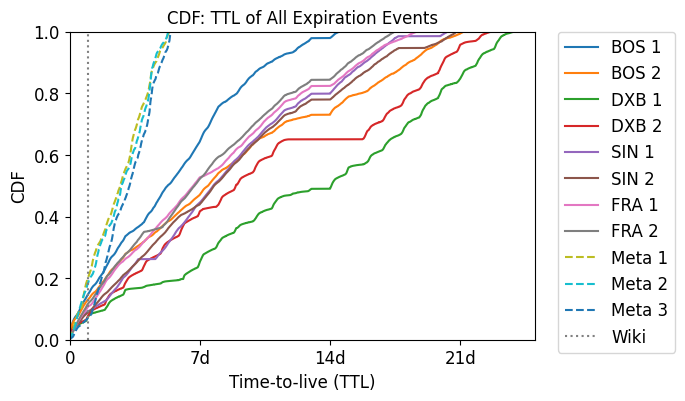

In [7]:
for i, g in df.groupby('in'):
    x_sorted = np.sort(g['ttl'])
    y_values = np.linspace(0, 1, len(x_sorted))
    style = get_linestyle(i)
    plt.plot(x_sorted, y_values, label=rename_tbl[i], linestyle=style, drawstyle='steps-post')

plt.axvline(86400, color='grey', linestyle=':', label='Wiki')

plt.xticks([0, 3600*24*7, 3600*24*14, 3600*24*21, 3600*24*30], ['0', '7d', '14d', '21d', '30d'])
plt.title('CDF: TTL of All Expiration Events')
plt.xlabel('Time-to-live (TTL)')
plt.ylabel('CDF')
plt.ylim(0, 1)
plt.xlim(0, 86400*25)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.savefig('../paper/figs/expiry_population_ttl_dist.png', bbox_inches='tight')
plt.show()

/tmp/ipykernel_916334/3027113354.py:4: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(-10, 7*24*3600)


(0.4778793344141689, 604800.0)

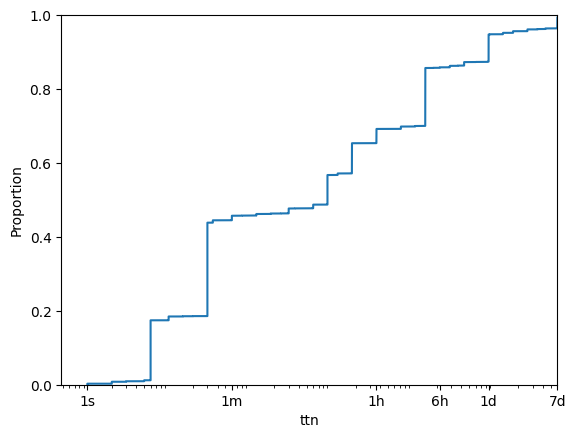

In [4]:
df['ttn'] = np.minimum(np.maximum(-1, (df['next_ts'] - df['ts'])), 30*24*3600)
sns.ecdfplot(df['ttn'], log_scale=True)
plt.xticks([1, 60, 60*60, 6*3600, 24*3600, 7*24*3600], ['1s', '1m', '1h', '6h', '1d', '7d'])
plt.xlim(-10, 7*24*3600)

/home/isaackhor/code/cfcache/.venv/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/home/isaackhor/code/cfcache/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


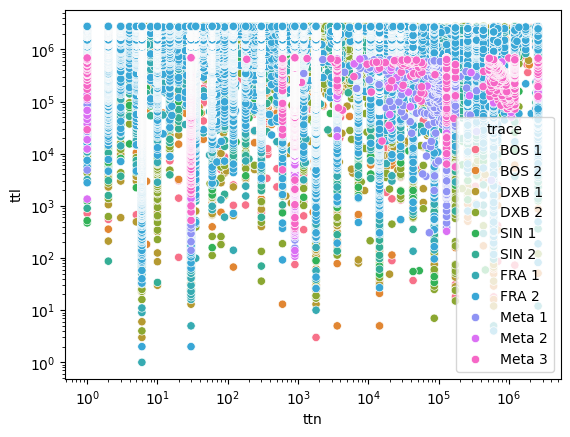

In [5]:
sns.scatterplot(data=df, x='ttn', y='ttl', hue='trace')
plt.xscale('log')
plt.yscale('log')

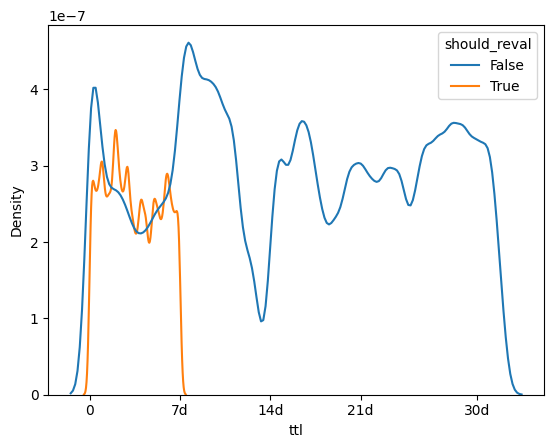

In [6]:
sns.kdeplot(data=df, x='ttl', hue='should_reval')
plt.xticks([0, 3600*24*7, 3600*24*14, 3600*24*21, 3600*24*30], ['0', '7d', '14d', '21d', '30d'])
plt.show()

([<matplotlib.axis.XTick at 0x730a6b0030e0>,
 [Text(0, 0, '0'),
  Text(604800, 0, '7d'),
  Text(1209600, 0, '14d'),
  Text(1814400, 0, '21d'),
  Text(2592000, 0, '30d')])

/home/isaackhor/code/cfcache/.venv/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/home/isaackhor/code/cfcache/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


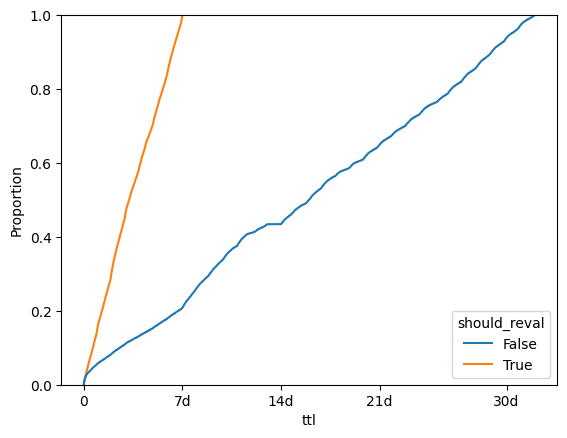

In [7]:
sns.ecdfplot(data=df, x='ttl', hue='should_reval')
plt.xticks([0, 3600*24*7, 3600*24*14, 3600*24*21, 3600*24*30], ['0', '7d', '14d', '21d', '30d'])
plt.show()

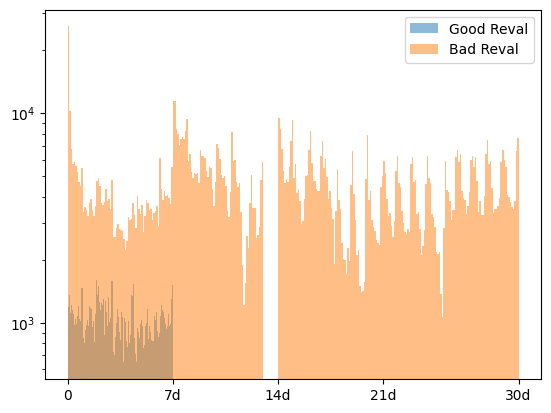

In [17]:
plt.hist(df[(df['ttl'] < 30*24*3600) & (df['should_reval'] == True)]['ttl'], label='Good Reval', alpha=0.5, bins=300)
plt.hist(df[(df['ttl'] < 30*24*3600) & (df['should_reval'] == False)]['ttl'], label='Bad Reval', alpha=0.5, bins=300)
plt.xticks([0, 3600*24*7, 3600*24*14, 3600*24*21, 3600*24*30], ['0', '7d', '14d', '21d', '30d'])
plt.yscale('log')
plt.legend()

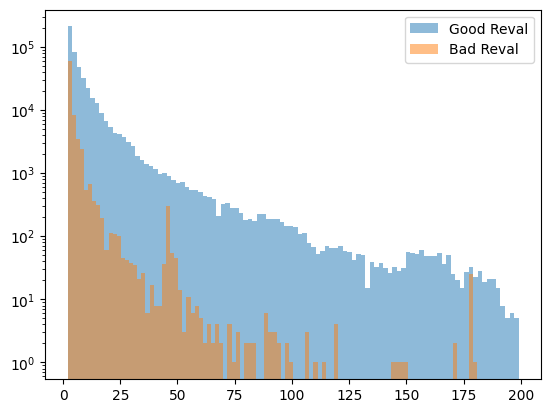

In [26]:
plt.hist(df_good[(df_good['generations'] > 1) & (df_good['generations'] < 200)]['generations'], label='Good Reval', alpha=0.5, bins=100)
plt.hist(df_bad[(df_bad['generations'] > 1) & (df_bad['generations'] < 200)]['generations'], label='Bad Reval', alpha=0.5, bins=100)
plt.yscale('log')
plt.legend()

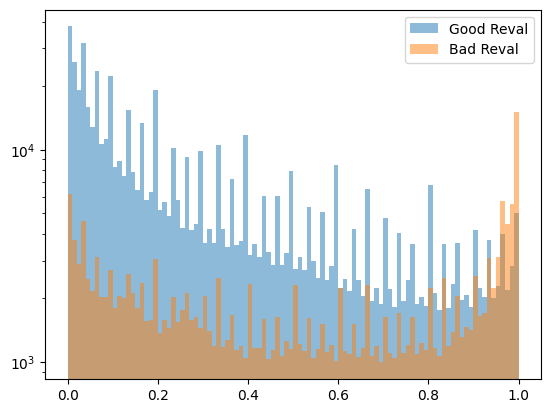

In [16]:
plt.hist(df_good[(df_good['t_since_last_frac'] > 0) & (df_good['t_since_last_frac'] < 1)]['t_since_last_frac'], label='Good Reval', alpha=0.5, bins=100)
plt.hist(df_bad[(df_bad['t_since_last_frac'] > 0) & (df_bad['t_since_last_frac'] < 1)]['t_since_last_frac'], label='Bad Reval', alpha=0.5, bins=100)
plt.yscale('log')
plt.legend()